

## **PROYECTO: RECYCLAR**

RecyclAr es una empresa dedicada al reciclaje de material metálico, cuya actividad principal es la compra de desechos ferrosos y no ferrosos para su clasificación, procesamiento y venta a las principales acerías Argentina. Actualmente la empresa cuenta con 3 puntos de reciclaje ubicados en la Provincia de Córdoba.



OBJETIVOS

Se plantea como objetivo predecir los volúmenes de compras de los distintos artículos en el próximo trimestre de los datos recopilados.

DATA SET
Se utilizan los datos de compras del periodo Enero 2.024 hasta el periodo Septiembre 2.024.

In [ ]:
# importar las librerias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install openpyxl

# Cargar la base de datos en Excel

URL = "https://raw.githubusercontent.com/EdduSzeta/data/main/RECYCLAR%20DS.xlsx"

data = pd.read_excel(URL)

df = pd.DataFrame(data)

df.head()

,Nro.Boleta,Remito,Fecha,Hora,Importe,PROVEEDOR,Operacion,Material,Observación,Articulo,KG,Dto,KG Neto,Precio,Total,Suc
0,695268.0,82136.0,2024-01-31,18:51:05,3300.0,PUB01,PUBLICO,METALES,NaN,COBRE,0.3,0.0,0.3,5300.0,1590.0,PR-01
1,695268.0,82136.0,2024-01-31,18:51:05,3300.0,PUB01,PUBLICO,METALES,NaN,BRONCE,0.6,0.0,0.6,2800.0,1680.0,PR-01
2,695268.0,82136.0,2024-01-31,18:51:05,3300.0,PUB01,PUBLICO,REDONDEO,NaN,REDONDEO,1.0,0.0,1.0,30.0,30.0,PR-01
3,695267.0,82135.0,2024-01-31,18:48:27,27000.0,PUB01,PUBLICO,METALES,NaN,COBRE,5.1,0.0,5.1,5300.0,27030.0,PR-01
4,695267.0,82135.0,2024-01-31,18:48:27,27000.0,PUB01,PUBLICO,REDONDEO,NaN,REDONDEO,1.0,0.0,1.0,-30.0,-30.0,PR-01


In [ ]:
df.shape


(331312, 16)

In [ ]:
df.head()

,Nro.Boleta,Remito,Fecha,Hora,Importe,PROVEEDOR,Operacion,Material,Observación,Articulo,KG,Dto,KG Neto,Precio,Total,Suc
0,695268.0,82136.0,2024-01-31,18:51:05,3300.0,PUB01,PUBLICO,METALES,NaN,COBRE,0.3,0.0,0.3,5300.0,1590.0,PR-01
1,695268.0,82136.0,2024-01-31,18:51:05,3300.0,PUB01,PUBLICO,METALES,NaN,BRONCE,0.6,0.0,0.6,2800.0,1680.0,PR-01
2,695268.0,82136.0,2024-01-31,18:51:05,3300.0,PUB01,PUBLICO,REDONDEO,NaN,REDONDEO,1.0,0.0,1.0,30.0,30.0,PR-01
3,695267.0,82135.0,2024-01-31,18:48:27,27000.0,PUB01,PUBLICO,METALES,NaN,COBRE,5.1,0.0,5.1,5300.0,27030.0,PR-01
4,695267.0,82135.0,2024-01-31,18:48:27,27000.0,PUB01,PUBLICO,REDONDEO,NaN,REDONDEO,1.0,0.0,1.0,-30.0,-30.0,PR-01


In [ ]:
df.tail()

,Nro.Boleta,Remito,Fecha,Hora,Importe,PROVEEDOR,Operacion,Material,Observación,Articulo,KG,Dto,KG Neto,Precio,Total,Suc
331307,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289072.0,0
331308,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289072.0,0
331309,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289071.0,0
331310,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289071.0,0
331311,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289071.0,0


In [ ]:
df.columns

Index(['Nro.Boleta', 'Remito', 'Fecha', 'Hora', 'Importe', 'PROVEEDOR',
       'Operacion', 'Material', 'Observación', 'Articulo', 'KG', 'Dto',
       'KG Neto', 'Precio', 'Total', 'Suc'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331312 entries, 0 to 331311
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Nro.Boleta   317246 non-null  float64       
 1   Remito       317246 non-null  float64       
 2   Fecha        317246 non-null  datetime64[ns]
 3   Hora         317246 non-null  object        
 4   Importe      317246 non-null  float64       
 5   PROVEEDOR    317246 non-null  object        
 6   Operacion    317246 non-null  object        
 7   Material     317246 non-null  object        
 8   Observación  46722 non-null   object        
 9   Articulo     317246 non-null  object        
 10  KG           317246 non-null  float64       
 11  Dto          317246 non-null  float64       
 12  KG Neto      317246 non-null  float64       
 13  Precio       317246 non-null  float64       
 14  Total        331307 non-null  float64       
 15  Suc          331307 non-null  obje

In [ ]:
df.describe()

,Nro.Boleta,Remito,Fecha,Importe,KG,Dto,KG Neto,Precio,Total
count,317246.000000,317246.000000,317246,3.172460e+05,317246.000000,317246.000000,317246.000000,317246.000000,3.313070e+05
mean,447872.393962,113420.091459,2024-05-04 10:35:07.442173952,1.286175e+04,12.923418,0.045578,12.877112,1325.249083,1.715583e+04
min,282461.000000,47.000000,2024-01-02 00:00:00,-3.759600e+01,-2.100000,0.000000,-2.100000,-5500.000000,-2.000000e+02
25%,318179.250000,57835.000000,2024-02-27 00:00:00,1.247500e+03,1.000000,0.000000,1.000000,11.500000,1.500000e+01
50%,421835.000000,106397.500000,2024-04-25 00:00:00,3.450000e+03,1.000000,0.000000,1.000000,102.000000,6.320000e+02
75%,457710.000000,175766.750000,2024-07-15 00:00:00,9.640000e+03,4.600000,0.000000,4.600000,1010.000000,3.712900e+03
max,723626.000000,239499.000000,2024-09-26 00:00:00,3.363212e+06,10855.000000,130.000000,10855.000000,8300.000000,3.353088e+06
std,147190.060691,57952.902799,NaN,4.649124e+04,79.849252,0.754327,79.770119,2122.015805,6.289921e+04


In [ ]:
#renombrar columnas
df.rename(columns={"Nro.Boleta": "BOLETA",
                   "Remito" : "REMITO",
                   "Fecha" : "FECHA" ,
                   "Hora" : "HORA" ,
                   "Operacion" : "OPERACION" ,
                   "Material" : "MATERIAL" ,
                   "Observación" : "OBSERVACION" ,
                   "Articulo" : "ARTICULO" ,
                   "Importe" : "MONTO",
                   "Dto":"DESC.",
                   "KG Neto" : "NETO",
                   "Precio": "PRECIO",
                   "Suc" : "PUNTORECICLAJE" ,
                   "Total" : "SUBTOTAL",
                   }, inplace=True  )

In [ ]:
df.columns

Index(['BOLETA', 'REMITO', 'FECHA', 'HORA', 'MONTO', 'PROVEEDOR', 'OPERACION',
       'MATERIAL', 'OBSERVACION', 'ARTICULO', 'KG', 'DESC.', 'NETO', 'PRECIO',
       'SUBTOTAL', 'PUNTORECICLAJE'],
      dtype='object')

LIMPIEZA DE DATASET

In [ ]:
UNICOS = df["PUNTORECICLAJE"].unique()
UNICOS

array(['PR-01', 'PR-02', 'PR-03', nan, 0], dtype=object)

In [ ]:
# Detección de valores perdidos

ERRORESPR = df[df['PUNTORECICLAJE']==0]

ERRORESPR

,BOLETA,REMITO,FECHA,HORA,MONTO,PROVEEDOR,OPERACION,MATERIAL,OBSERVACION,ARTICULO,KG,DESC.,NETO,PRECIO,SUBTOTAL,PUNTORECICLAJE
317251,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295448.0,0
317252,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295448.0,0
317253,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295447.0,0
317254,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295447.0,0
317255,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295446.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331307,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289072.0,0
331308,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289072.0,0
331309,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289071.0,0
331310,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,289071.0,0


In [ ]:
# Límpieza de valores perdidos

df_clean = df.drop(df[df['PUNTORECICLAJE']==0].index)

ERRORESPR = df_clean[df_clean['PUNTORECICLAJE']==0]

ERRORESPR

,BOLETA,REMITO,FECHA,HORA,MONTO,PROVEEDOR,OPERACION,MATERIAL,OBSERVACION,ARTICULO,KG,DESC.,NETO,PRECIO,SUBTOTAL,PUNTORECICLAJE


In [ ]:
# Renombrar valores de artículos

df_clean ["ARTICULO"] = df.clean["ARTICULO"].replace ({
REDONDEO
ALU BLANDO
COBRE
PESADA P CAMION/DEP
LIVIANA P DEP/CAMION
BRONCE
PLOMO REZAGO
BATERIAS CON LIQUIDO
BATER. MOTOS INDUSTR EBONIT
AMORTIGUADOR S/CORTA
S/DIM PESADA-P CAM/D
PASTA
BATERIA
ESTAÑADO
ALUMINIO SUCIO
BOCHAS HELADERA
RADIADORES DE BRONCE
ACERO INOXIDABLE
RAEE DE BAJA
ALU PERFIL
VIRUTA HIERRO
ALU CARTER
CABLE DE COBRE CON PVC
ALU UBC
VIRUTA DE ALUMINIO
VIRUTA BRONCE
CABLE ALUM CON PVC
CABLE ALUM. C/ALMA ACERO
S/DIM LIVIANA
RADIADORES COBREALUMINIO
})

SyntaxError: invalid syntax (<ipython-input-27-30aee0920e07>, line 4)

GRAFICOS

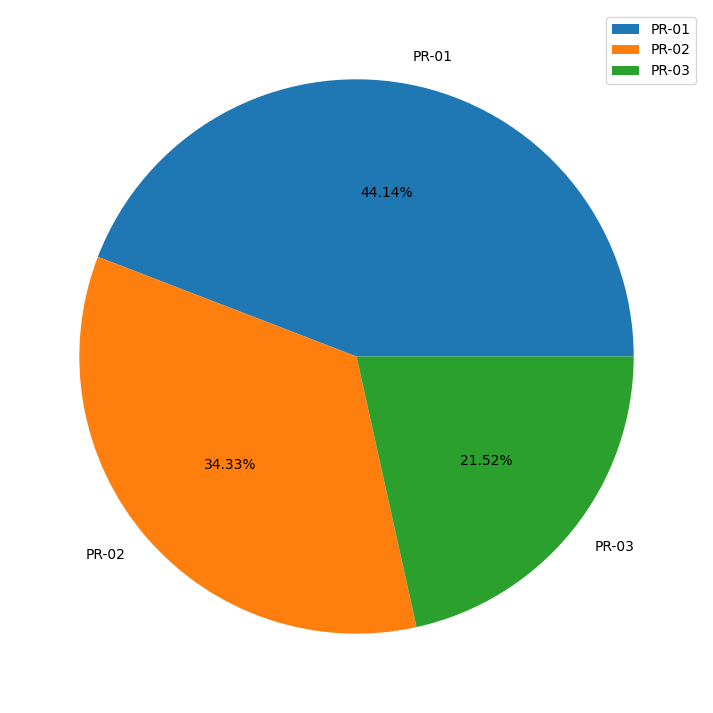

In [ ]:
#Proporción de compras por Puntos de Reciclaje
df_PR = df_clean["PUNTORECICLAJE"].value_counts()
fig,ax=plt.subplots(figsize=(9,9))
Punto_Reciclaje =['PR-01','PR-02','PR-03']
ax.pie(df_PR, labels = Punto_Reciclaje , autopct="%.2f%%" )
ax.legend()
plt.show()

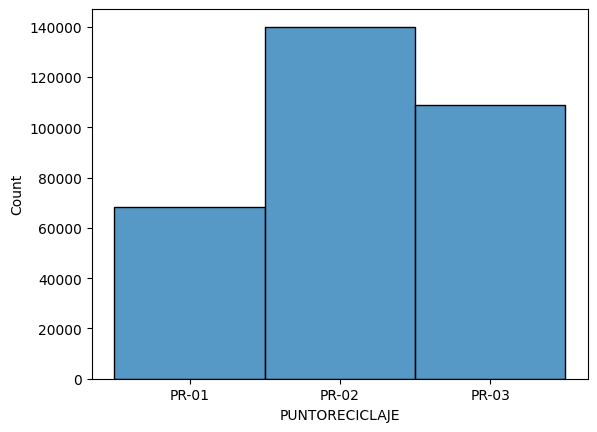

In [ ]:
##Cantidad de compras por Puntos de Reciclaje

sns.histplot(x="PUNTORECICLAJE", data=df_clean)
plt.show()

In [ ]:
# Cantidad de kg comprados por Punto de Reciclaje

PR_KG = df_clean.groupby("PUNTORECICLAJE")["NETO"].sum()
PR_KG

,NETO
PUNTORECICLAJE,
PR-01,802916.60
PR-02,2351198.91
PR-03,931096.89


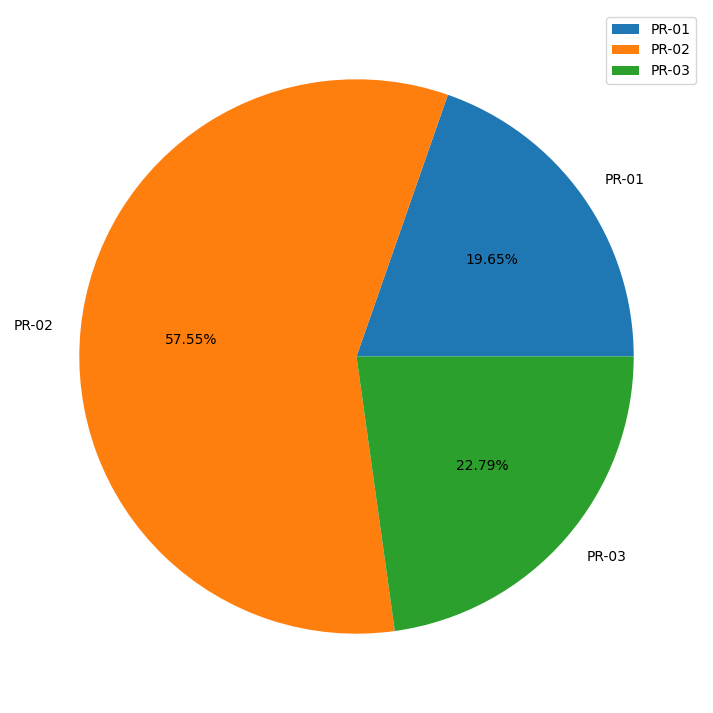

In [ ]:
# Proporción de kg comprados por Punto de Reciclaje

fig, ax = plt.subplots(figsize=(9,9))
ax.pie(PR_KG, labels = Punto_Reciclaje , autopct="%.2f%%" )
ax.legend()
plt.show()

In [ ]:
df_clean["ARTICULO"].value_counts()

,count
ARTICULO,
REDONDEO,113960
ALU BLANDO,50193
COBRE,48006
PESADA P CAMION/DEP,28846
LIVIANA P DEP/CAMION,25117
BRONCE,23253
PLOMO REZAGO,5979
BATERIAS CON LIQUIDO,4263
BATER. MOTOS INDUSTR EBONIT,3878


In [ ]:
# cantidad de kg por articulo

df_ARTKG = df_clean.groupby("ARTICULO")["NETO"].sum()
df_ARTKG

,NETO
ARTICULO,
ACERO INOXIDABLE,6608.61
ALU BLANDO,227025.87
ALU CARTER,7778.88
ALU PERFIL,6784.17
ALU UBC,3035.81
ALUMINIO SUCIO,2582.72
AMORTIGUADOR S/CORTA,58427.98
BATER. MOTOS INDUSTR EBONIT,70482.89
BATERIA,47269.78


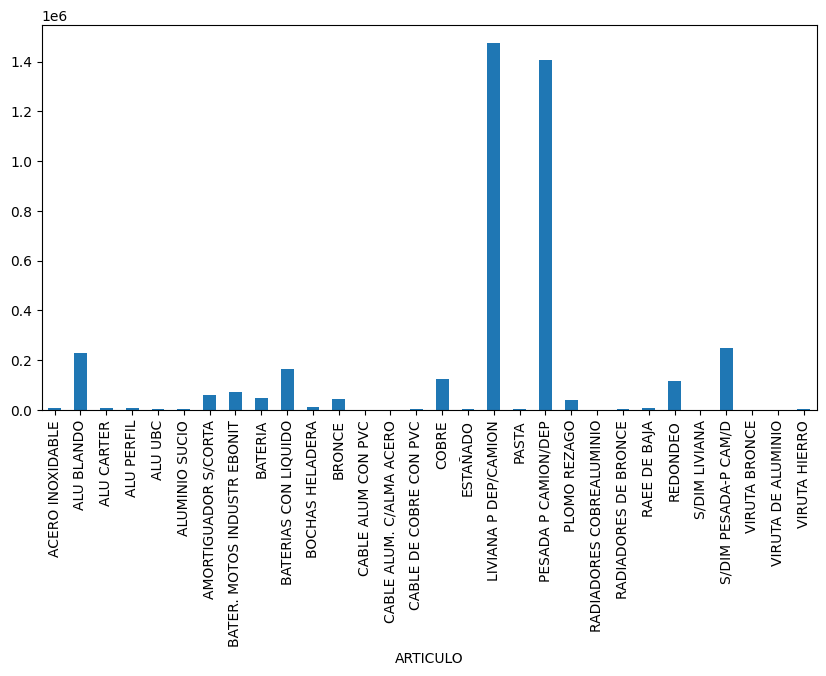

In [ ]:
# grafico cantidad por artículo

df_ARTKG.plot(kind="bar", figsize=(10,5))
plt.show()